## Import Libraries

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.20.0


## Load Dataset

In [48]:
df = pd.read_csv('/home/denypratamas/projects/studygroupdl/titanic/train.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Data Preprocessing

In [49]:
# Cek missing values
print("Missing values:")
print(df.isnull().sum())

Missing values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [50]:
# Handle missing values
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Drop kolom yang tidak relevan
df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)

print(f"Shape setelah drop: {df.shape}")
df.head()

Shape setelah drop: (891, 8)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [51]:
# Encode categorical variables
le_sex = LabelEncoder()
le_embarked = LabelEncoder()

df['Sex'] = le_sex.fit_transform(df['Sex'])
df['Embarked'] = le_embarked.fit_transform(df['Embarked'])

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


In [52]:
# Split features dan target
X = df.drop('Survived', axis=1)
y = df['Survived']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (891, 7)
Target shape: (891,)


In [53]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

Train shape: (712, 7)
Test shape: (179, 7)


In [ ]:
# Model builder function
def build_model(n_layers, neurons_per_layer, learning_rate, optimizer_name='adam', input_dim=7):
    """
    Args:
        n_layers: jumlah hidden layers
        neurons_per_layer: list jumlah neuron per layer
        learning_rate: learning rate
        optimizer_name: 'adam', 'sgd', atau 'rmsprop'
        input_dim: dimensi input
    """
    model = Sequential()
    
    # Input layer
    model.add(Dense(neurons_per_layer[0], activation='relu', input_dim=input_dim))
    model.add(BatchNormalization())
    model.add(Dropout(0.3))
    
    # Hidden layers
    for i in range(1, n_layers):
        model.add(Dense(neurons_per_layer[i], activation='relu'))
        model.add(BatchNormalization())
        model.add(Dropout(0.3))
    
    # Output layer
    model.add(Dense(1, activation='sigmoid'))
    
    # Optimizer
    if optimizer_name == 'adam':
        optimizer = Adam(learning_rate=learning_rate)
    elif optimizer_name == 'sgd':
        optimizer = SGD(learning_rate=learning_rate, momentum=0.9)
    else:
        optimizer = RMSprop(learning_rate=learning_rate)
    
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    
    return model

## Callbacks Setup

Early stopping untuk menghentikan training jika tidak ada improvement. ReduceLROnPlateau untuk menurunkan learning rate jika loss stagnan.

In [55]:
def get_callbacks():
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    )
    
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
    
    return [early_stop, reduce_lr]

## Plotting Function

In [56]:
def plot_history(history, title):
    """Plot accuracy dan loss dari training history."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Accuracy plot
    axes[0].plot(history.history['accuracy'], label='Train Accuracy')
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
    axes[0].set_title(f'{title} - Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True)
    
    # Loss plot
    axes[1].plot(history.history['loss'], label='Train Loss')
    axes[1].plot(history.history['val_loss'], label='Val Loss')
    axes[1].set_title(f'{title} - Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True)
    
    plt.tight_layout()
    plt.show()

# Variasi Jumlah Layer dan Neuron

2 vs 4 layers

### Model A (2 Hidden Layers)

In [57]:
# Shallow network: 2 hidden layers
model_shallow = build_model(
    n_layers=2,
    neurons_per_layer=[64, 32],
    learning_rate=0.001,
    optimizer_name='adam'
)

model_shallow.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_40 (Dense)                │ (None, 64)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,009 (11.75 KB)

 Trainable params: 2,817 (11.00 KB)

 Non-trainable params: 192 (768.00 B)

In [58]:
# Train shallow model
history_shallow = model_shallow.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=get_callbacks(),
    verbose=1
)

Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.6587 - loss: 0.6892 - val_accuracy: 0.6927 - val_loss: 0.5859 - learning_rate: 0.0010
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7444 - loss: 0.6160 - val_accuracy: 0.7207 - val_loss: 0.5590 - learning_rate: 0.0010
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7823 - loss: 0.5593 - val_accuracy: 0.7263 - val_loss: 0.5474 - learning_rate: 0.0010
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7795 - loss: 0.5066 - val_accuracy: 0.7374 - val_loss: 0.5332 - learning_rate: 0.0010
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7851 - loss: 0.5002 - val_accuracy: 0.7654 - val_loss: 0.5248 - learning_rate: 0.0010
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7711 - loss: 0.5147 - val_accuracy: 0.7654 - val_loss: 0.5048 - learning_rate: 0.0010
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8034 - loss: 0.4693 - val_ac

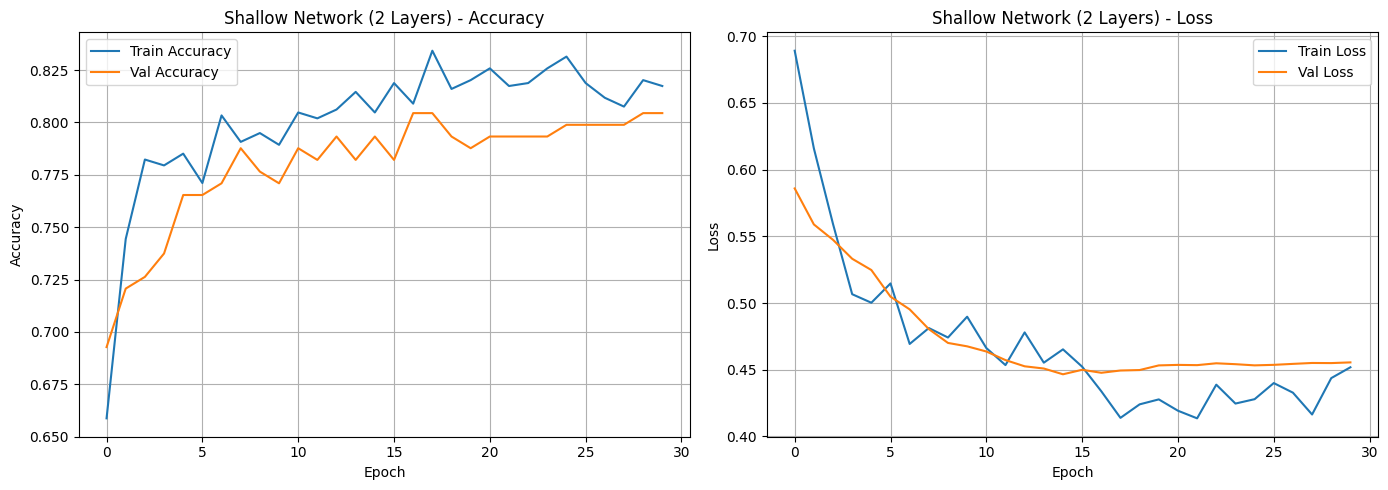

In [59]:
plot_history(history_shallow, 'Shallow Network (2 Layers)')

In [60]:
# Evaluate shallow model
loss_shallow, acc_shallow = model_shallow.evaluate(X_test, y_test, verbose=0)
print(f"Shallow Network - Test Accuracy: {acc_shallow:.4f}, Test Loss: {loss_shallow:.4f}")

Shallow Network - Test Accuracy: 0.7933, Test Loss: 0.4466


### Model B (4 Hidden Layers)

In [61]:
# Deep network: 4 hidden layers
model_deep = build_model(
    n_layers=4,
    neurons_per_layer=[128, 64, 32, 16],
    learning_rate=0.001,
    optimizer_name='adam'
)

model_deep.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_43 (Dense)                │ (None, 128)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_32          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_33          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_34          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_35          │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_35 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,865 (50.25 KB)

 Trainable params: 12,385 (48.38 KB)

 Non-trainable params: 480 (1.88 KB)

In [62]:
# Train deep model
history_deep = model_deep.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=get_callbacks(),
    verbose=1
)

Epoch 1/100


23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.6124 - loss: 0.7729 - val_accuracy: 0.7709 - val_loss: 0.6417 - learning_rate: 0.0010
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6713 - loss: 0.6721 - val_accuracy: 0.8045 - val_loss: 0.6079 - learning_rate: 0.0010
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7219 - loss: 0.6266 - val_accuracy: 0.7709 - val_loss: 0.5764 - learning_rate: 0.0010
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7331 - loss: 0.5968 - val_accuracy: 0.7709 - val_loss: 0.5537 - learning_rate: 0.0010
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7346 - loss: 0.5702 - val_accuracy: 0.7877 - val_loss: 0.5323 - learning_rate: 0.0010
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7584 - loss: 0.5276 - val_accuracy: 0.7821 - val_loss: 0.5211 - learning_rate: 0.0010
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7711 - loss: 0.5214 - val_accuracy: 0.

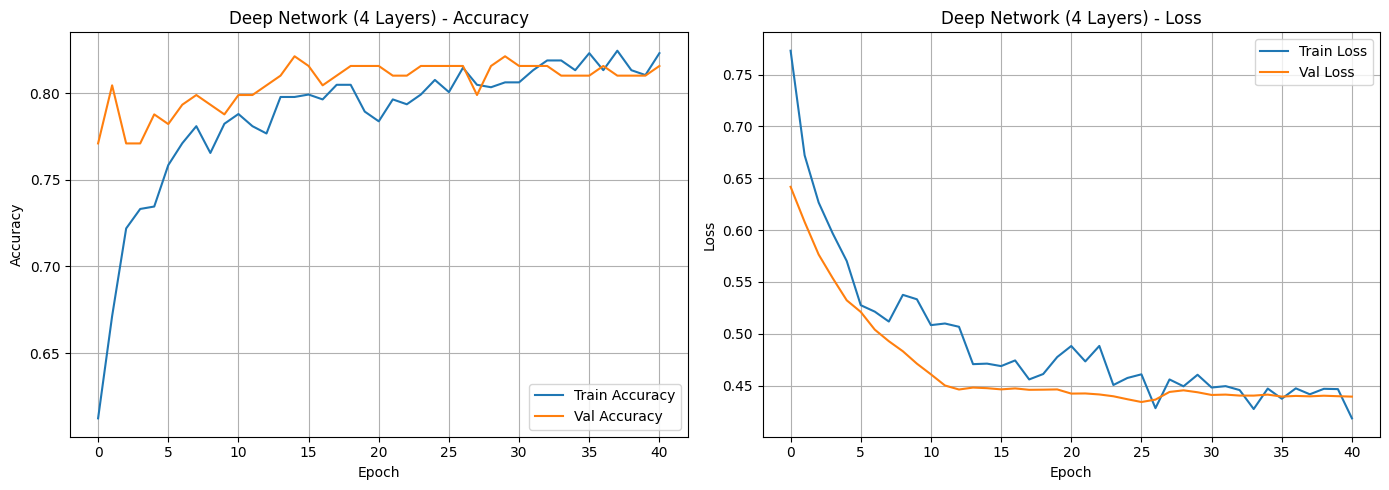

In [63]:
plot_history(history_deep, 'Deep Network (4 Layers)')

In [64]:
# Evaluate deep model
loss_deep, acc_deep = model_deep.evaluate(X_test, y_test, verbose=0)
print(f"Deep Network - Test Accuracy: {acc_deep:.4f}, Test Loss: {loss_deep:.4f}")

Deep Network - Test Accuracy: 0.8156, Test Loss: 0.4343



# Variasi Learning Rate

0.001 vs 0.01 vs 0.0001

In [65]:
learning_rates = [0.001, 0.01, 0.0001]
lr_results = {}

In [66]:
# LR = 0.001
model_lr1 = build_model(n_layers=3, neurons_per_layer=[64, 32, 16], learning_rate=0.001, optimizer_name='adam')
history_lr1 = model_lr1.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test), callbacks=get_callbacks(), verbose=0)
lr_results['lr_0.001'] = history_lr1
print(f"LR=0.001 done. Val Accuracy: {max(history_lr1.history['val_accuracy']):.4f}")


Epoch 32: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 37: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 42: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
Epoch 42: early stopping
Restoring model weights from the end of the best epoch: 27.
LR=0.001 done. Val Accuracy: 0.8101


In [67]:
# LR = 0.01
model_lr2 = build_model(n_layers=3, neurons_per_layer=[64, 32, 16], learning_rate=0.01, optimizer_name='adam')
history_lr2 = model_lr2.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test), callbacks=get_callbacks(), verbose=0)
lr_results['lr_0.01'] = history_lr2
print(f"LR=0.01 done. Val Accuracy: {max(history_lr2.history['val_accuracy']):.4f}")


Epoch 23: ReduceLROnPlateau reducing learning rate to 0.004999999888241291.

Epoch 29: ReduceLROnPlateau reducing learning rate to 0.0024999999441206455.

Epoch 35: ReduceLROnPlateau reducing learning rate to 0.0012499999720603228.

Epoch 40: ReduceLROnPlateau reducing learning rate to 0.0006249999860301614.

Epoch 49: ReduceLROnPlateau reducing learning rate to 0.0003124999930150807.

Epoch 54: ReduceLROnPlateau reducing learning rate to 0.00015624999650754035.

Epoch 59: ReduceLROnPlateau reducing learning rate to 7.812499825377017e-05.
Epoch 60: early stopping
Restoring model weights from the end of the best epoch: 45.
LR=0.01 done. Val Accuracy: 0.8212


In [68]:
# LR = 0.0001
model_lr3 = build_model(n_layers=3, neurons_per_layer=[64, 32, 16], learning_rate=0.0001, optimizer_name='adam')
history_lr3 = model_lr3.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test), callbacks=get_callbacks(), verbose=0)
lr_results['lr_0.0001'] = history_lr3
print(f"LR=0.0001 done. Val Accuracy: {max(history_lr3.history['val_accuracy']):.4f}")


Epoch 6: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 11: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
Restoring model weights from the end of the best epoch: 100.
LR=0.0001 done. Val Accuracy: 0.7877


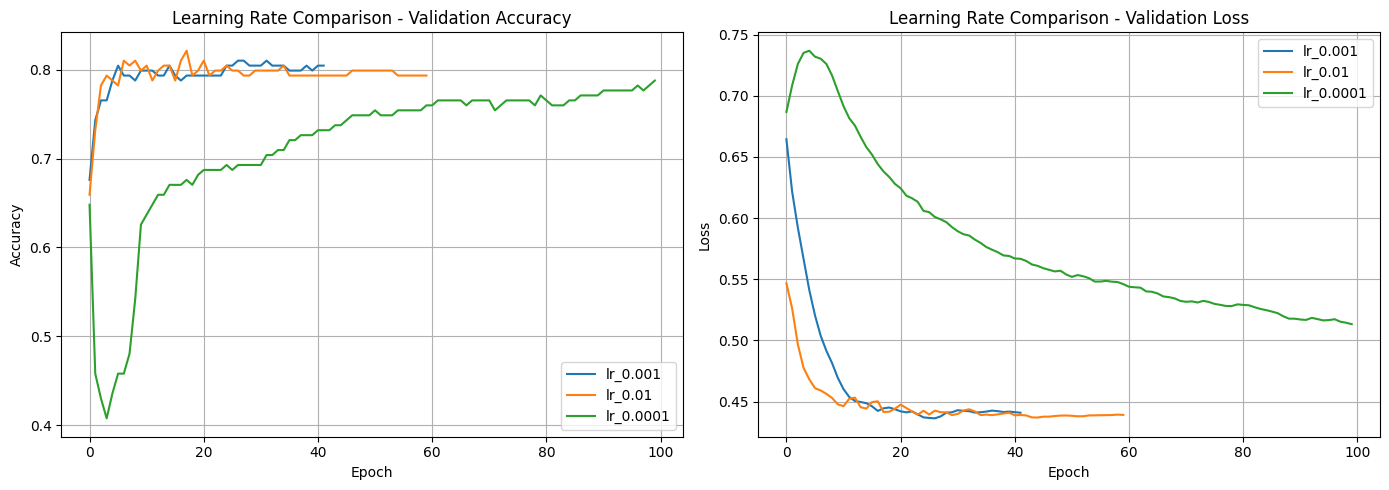

In [69]:
# Plot learning rate comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, history in lr_results.items():
    axes[0].plot(history.history['val_accuracy'], label=name)
    axes[1].plot(history.history['val_loss'], label=name)

axes[0].set_title('Learning Rate Comparison - Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].set_title('Learning Rate Comparison - Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


# Variasi Optimizer

Adam vs SGD vs RMSprop

In [70]:
optimizers = ['adam', 'sgd', 'rmsprop']
opt_results = {}

In [71]:
# Adam optimizer
model_adam = build_model(n_layers=3, neurons_per_layer=[64, 32, 16], learning_rate=0.001, optimizer_name='adam')
history_adam = model_adam.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test), callbacks=get_callbacks(), verbose=0)
opt_results['adam'] = history_adam
print(f"Adam done. Val Accuracy: {max(history_adam.history['val_accuracy']):.4f}")


Epoch 25: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 30: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 35: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
Epoch 35: early stopping
Restoring model weights from the end of the best epoch: 20.
Adam done. Val Accuracy: 0.8156


In [72]:
# SGD optimizer
model_sgd = build_model(n_layers=3, neurons_per_layer=[64, 32, 16], learning_rate=0.01, optimizer_name='sgd')
history_sgd = model_sgd.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test), callbacks=get_callbacks(), verbose=0)
opt_results['sgd'] = history_sgd
print(f"SGD done. Val Accuracy: {max(history_sgd.history['val_accuracy']):.4f}")


Epoch 19: ReduceLROnPlateau reducing learning rate to 0.004999999888241291.

Epoch 24: ReduceLROnPlateau reducing learning rate to 0.0024999999441206455.

Epoch 29: ReduceLROnPlateau reducing learning rate to 0.0012499999720603228.
Epoch 29: early stopping
Restoring model weights from the end of the best epoch: 14.
SGD done. Val Accuracy: 0.8268


In [73]:
# RMSprop optimizer
model_rmsprop = build_model(n_layers=3, neurons_per_layer=[64, 32, 16], learning_rate=0.001, optimizer_name='rmsprop')
history_rmsprop = model_rmsprop.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test), callbacks=get_callbacks(), verbose=0)
opt_results['rmsprop'] = history_rmsprop
print(f"RMSprop done. Val Accuracy: {max(history_rmsprop.history['val_accuracy']):.4f}")


Epoch 27: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 32: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 37: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
Epoch 37: early stopping
Restoring model weights from the end of the best epoch: 22.
RMSprop done. Val Accuracy: 0.8268


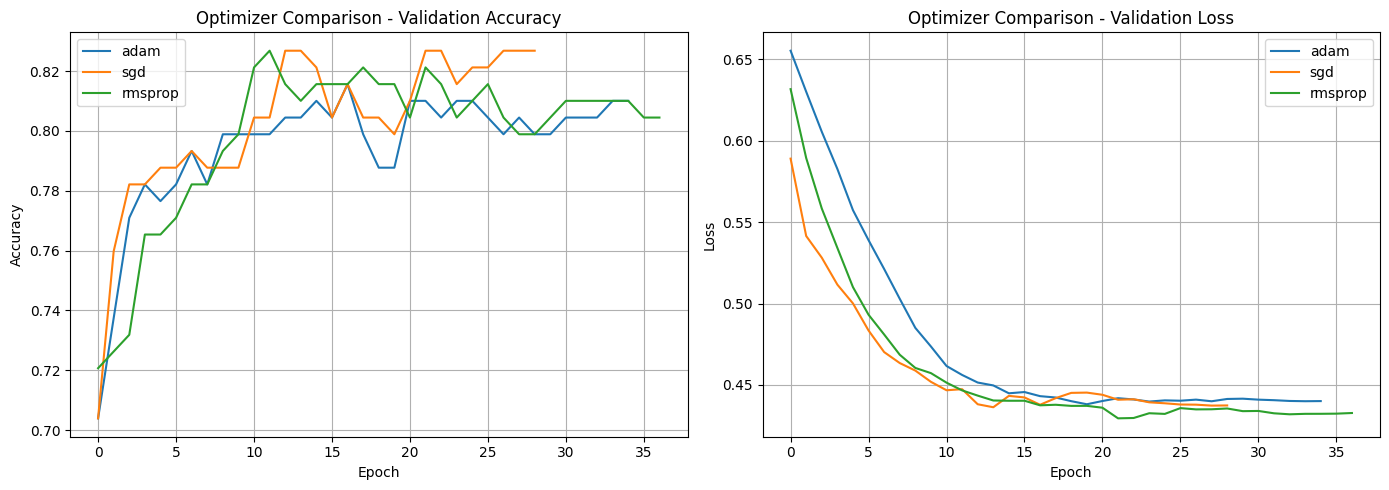

In [74]:
# Plot optimizer comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, history in opt_results.items():
    axes[0].plot(history.history['val_accuracy'], label=name)
    axes[1].plot(history.history['val_loss'], label=name)

axes[0].set_title('Optimizer Comparison - Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].set_title('Optimizer Comparison - Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Callbacks

In [75]:
# Model tanpa callbacks
model_no_cb = build_model(n_layers=3, neurons_per_layer=[64, 32, 16], learning_rate=0.001, optimizer_name='adam')
history_no_cb = model_no_cb.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=None,
    verbose=0
)
print(f"No Callbacks - Val Accuracy: {max(history_no_cb.history['val_accuracy']):.4f}")

No Callbacks - Val Accuracy: 0.8156


In [76]:
# Model dengan callbacks
model_with_cb = build_model(n_layers=3, neurons_per_layer=[64, 32, 16], learning_rate=0.001, optimizer_name='adam')
history_with_cb = model_with_cb.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=get_callbacks(),
    verbose=0
)
print(f"With Callbacks - Val Accuracy: {max(history_with_cb.history['val_accuracy']):.4f}")


Epoch 30: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 35: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 40: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
Epoch 40: early stopping
Restoring model weights from the end of the best epoch: 25.
With Callbacks - Val Accuracy: 0.8156


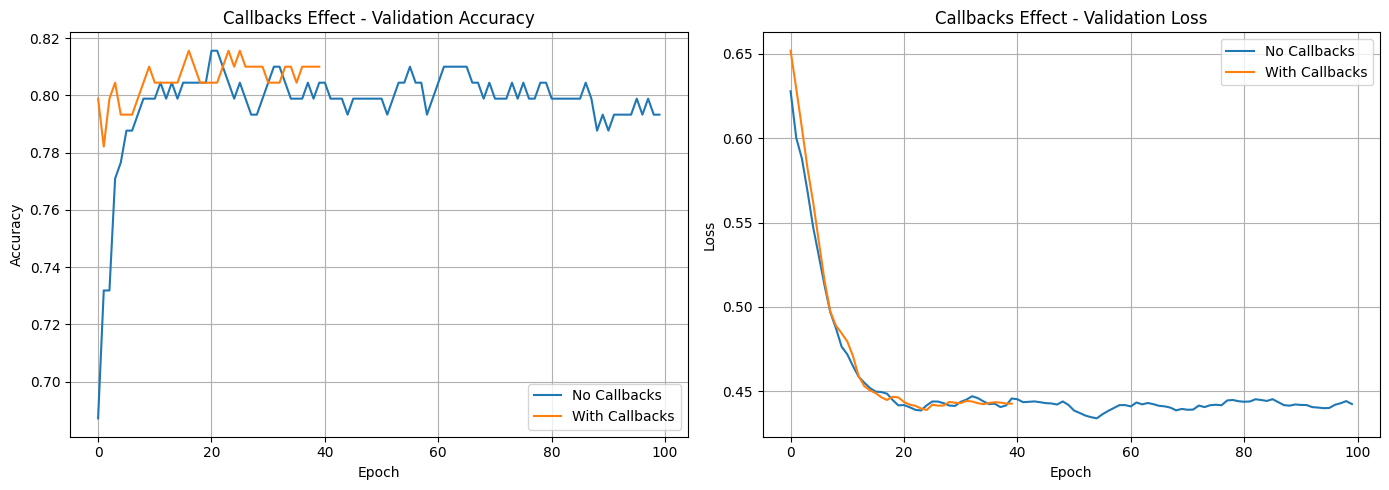

In [77]:
# Plot callbacks comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_no_cb.history['val_accuracy'], label='No Callbacks')
axes[0].plot(history_with_cb.history['val_accuracy'], label='With Callbacks')
axes[0].set_title('Callbacks Effect - Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history_no_cb.history['val_loss'], label='No Callbacks')
axes[1].plot(history_with_cb.history['val_loss'], label='With Callbacks')
axes[1].set_title('Callbacks Effect - Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [78]:
print(f"No Callbacks - Epochs trained: {len(history_no_cb.history['loss'])}")
print(f"With Callbacks - Epochs trained: {len(history_with_cb.history['loss'])}")

No Callbacks - Epochs trained: 100
With Callbacks - Epochs trained: 40


In [ ]:
results = {
    'Shallow (2 Layers)': model_shallow.evaluate(X_test, y_test, verbose=0),
    'Deep (4 Layers)': model_deep.evaluate(X_test, y_test, verbose=0),
    'LR=0.001': model_lr1.evaluate(X_test, y_test, verbose=0),
    'LR=0.01': model_lr2.evaluate(X_test, y_test, verbose=0),
    'LR=0.0001': model_lr3.evaluate(X_test, y_test, verbose=0),
    'Adam': model_adam.evaluate(X_test, y_test, verbose=0),
    'SGD': model_sgd.evaluate(X_test, y_test, verbose=0),
    'RMSprop': model_rmsprop.evaluate(X_test, y_test, verbose=0),
    'No Callbacks': model_no_cb.evaluate(X_test, y_test, verbose=0),
    'With Callbacks': model_with_cb.evaluate(X_test, y_test, verbose=0)
}

summary_df = pd.DataFrame([(k, v[1], v[0]) for k, v in results.items()], 
                          columns=['Model', 'Accuracy', 'Loss'])
summary_df = summary_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)
summary_df

,Model,Accuracy,Loss
0,SGD,0.826816,0.436307
1,RMSprop,0.821229,0.429496
2,Deep (4 Layers),0.815642,0.434269
3,LR=0.001,0.810056,0.436303
4,With Callbacks,0.810056,0.438849
5,Shallow (2 Layers),0.793296,0.446572
6,LR=0.01,0.793296,0.436984
7,No Callbacks,0.793296,0.442375
8,Adam,0.787709,0.438139
9,LR=0.0001,0.787709,0.513254


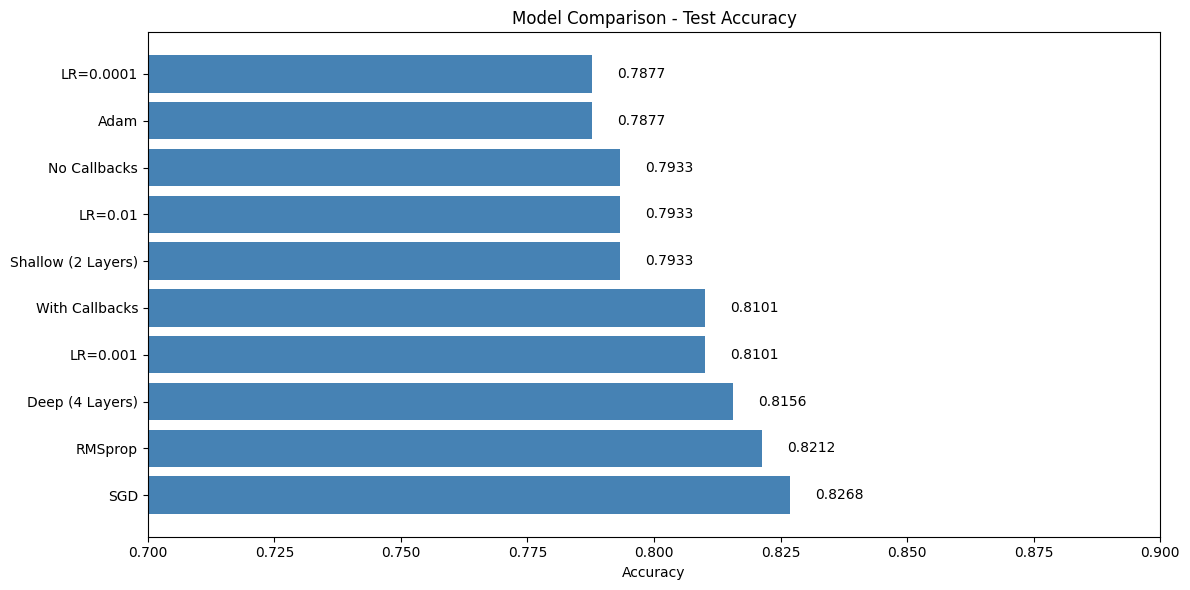

In [80]:
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(summary_df['Model'], summary_df['Accuracy'], color='steelblue')
ax.set_xlabel('Accuracy')
ax.set_title('Model Comparison - Test Accuracy')
ax.set_xlim(0.7, 0.9)

for bar, acc in zip(bars, summary_df['Accuracy']):
    ax.text(acc + 0.005, bar.get_y() + bar.get_height()/2, f'{acc:.4f}', va='center')

plt.tight_layout()
plt.show()

In [ ]:
# Generate Submission
print("Loading test data...")
df_test = pd.read_csv('titanic/test.csv')
passenger_ids = df_test['PassengerId']

# Preprocessing (matching training data logic)
df_test['Age'].fillna(df['Age'].median(), inplace=True)
df_test['Fare'].fillna(df['Fare'].median(), inplace=True)
df_test['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

df_test.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)

df_test['Sex'] = le_sex.transform(df_test['Sex'])
df_test['Embarked'] = le_embarked.transform(df_test['Embarked'])

# Standardize
X_submission = scaler.transform(df_test)

# Predict
print("Predicting...")
submission_preds = model_deep.predict(X_submission)
submission_classes = (submission_preds > 0.5).astype(int).flatten()

# Submission
submission = pd.DataFrame({
    'PassengerId': passenger_ids,
    'Survived': submission_classes
})

submission.to_csv('titanic/submission.csv', index=False)
print("Submission saved to titanic/submission.csv")
submission.head()

Loading test data...
Predicting...
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Submission saved to titanic/submission.csv


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0


Skor akurasi di kaggle titanic 0.77751